# Preprocessed Pipeline Analysis

This notebook explores the cleaned paired table, response-level text features, missingness, and quality artifacts before downstream evaluation.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
paired = pd.read_csv(PROCESSED / 'paired_answers_clean.csv')
metrics = pd.read_csv(PROCESSED / 'response_level_metrics.csv')
missingness = pd.read_csv(PROCESSED / 'missingness_report.csv')
artifacts = pd.read_csv(PROCESSED / 'quality_artifacts_report.csv')
stats = pd.read_csv(PROCESSED / 'response_statistics.csv')
print(f'Project root: {PROJECT_ROOT}')
print(f'Paired rows: {len(paired):,}; response rows: {len(metrics):,}')

Project root: c:\Users\prabh\Documents\Interview Prep\tmp2
Paired rows: 30; response rows: 60


## Dataset Overview

In [2]:
display(paired.head())
display(paired[['Person ID', 'Question Category']].value_counts().rename('count').reset_index())
display(missingness)

,Person ID,Question Category,Question Text,Human Answer,AI Answer
0,c_human,shopping behavior,where do you typically purchase your personal ...,"i usually buy my products online, as this give...",i typically purchase my personal care products...
1,s_human,shopping behavior,where do you typically purchase your personal ...,i usually order my face products online from y...,i typically purchase my personal care products...
2,g_human,shopping behavior,where do you typically purchase your personal ...,i almost always get all my personal care produ...,i typically purchase my personal care products...
3,c_human,product preferences,which personal care brands do you buy most oft...,i don't really know the brands. i buy them bec...,i usually stick with brands that offer simple ...
4,s_human,product preferences,which personal care brands do you buy most oft...,for my face i mostly use korean products like ...,i mostly buy skincare products from korean bra...


,Person ID,Question Category,count
0,c_human,product preferences,5
1,s_human,product preferences,5
2,g_human,product preferences,5
3,c_human,shopping behavior,3
4,s_human,shopping behavior,3
5,g_human,shopping behavior,3
6,c_human,influences,1
7,s_human,influences,1
8,g_human,influences,1
9,c_human,brand loyalty,1


,field,missing_count,missing_percent,unique_count
0,Person ID,0,0.0,3
1,Question Category,0,0.0,4
2,Question Text,0,0.0,10
3,Human Answer,0,0.0,30
4,AI Answer,0,0.0,30


## Missingness and Quality Artifacts

,row_number,response_type,artifact,detail
0,3,AI,non_ascii_characters,😊
1,12,AI,non_ascii_characters,😊
2,15,AI,non_ascii_characters,’
3,18,AI,non_ascii_characters,😊
4,20,AI,non_ascii_characters,—’
5,21,AI,non_ascii_characters,’
6,22,AI,non_ascii_characters,—’
7,23,AI,non_ascii_characters,–—’
8,24,AI,non_ascii_characters,–’
9,25,AI,non_ascii_characters,’


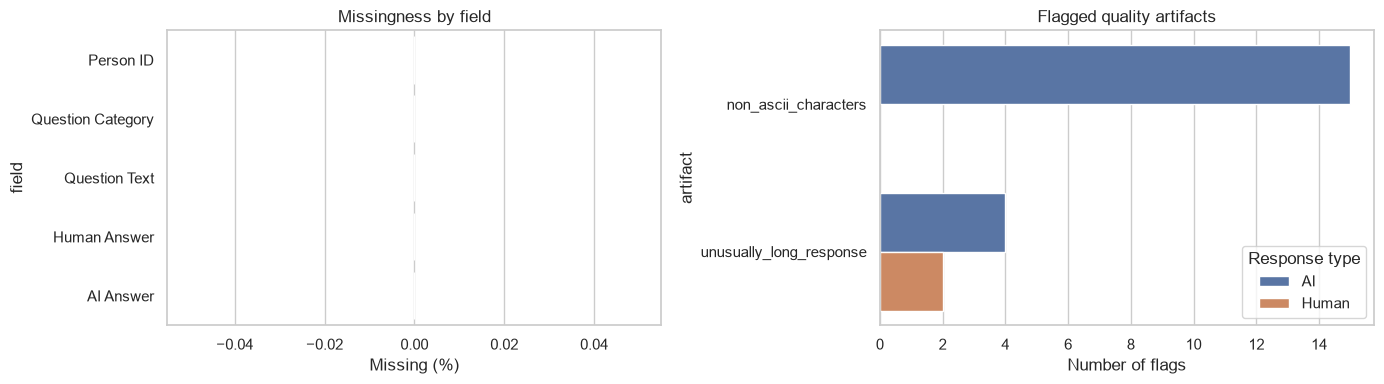

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=missingness, x='missing_percent', y='field', ax=axes[0], color='#2a9d8f')
axes[0].set_title('Missingness by field')
axes[0].set_xlabel('Missing (%)')
sns.countplot(data=artifacts, y='artifact', hue='response_type', ax=axes[1])
axes[1].set_title('Flagged quality artifacts')
axes[1].set_xlabel('Number of flags')
axes[1].legend(title='Response type')
plt.tight_layout()
display(artifacts)

## Response Length and Lexical Diversity

word_count                                                  \
                   count    mean     std   min   25%   50%    75%    max   
response_type                                                              
AI                  30.0  54.500  18.013  30.0  47.0  49.5  60.00  101.0   
Human               30.0  31.167  15.245   4.0  21.5  29.0  35.75   75.0   

              character_count           ...               lexical_diversity  \
                        count     mean  ...    75%    max             count   
response_type                           ...                                   
AI                       30.0  317.167  ...  372.0  560.0              30.0   
Human                    30.0  172.033  ...  190.0  398.0              30.0   

                                                                
                mean    std    min    25%    50%    75%    max  
response_type                                                   
AI             0.828  0.055  0.683  0.802  0.839  0.868  0.898  
Human          0.859  0.097  0.653  0.812  0.876  0.913  1.000  

[2 rows x 24 columns]

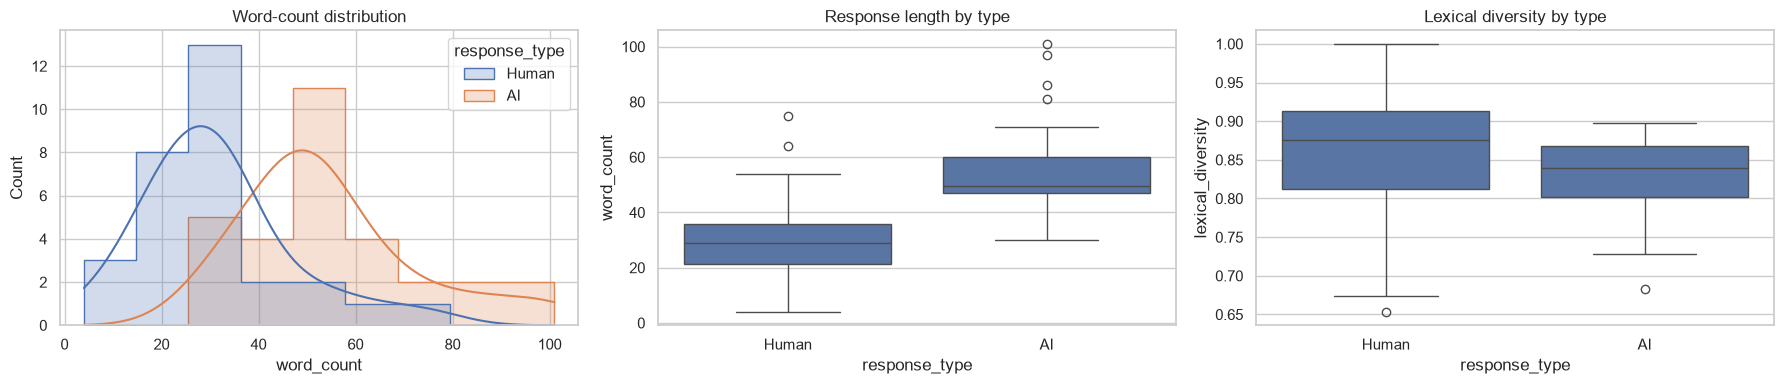

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(data=metrics, x='word_count', hue='response_type', kde=True, element='step', ax=axes[0])
axes[0].set_title('Word-count distribution')
sns.boxplot(data=metrics, x='response_type', y='word_count', ax=axes[1])
axes[1].set_title('Response length by type')
sns.boxplot(data=metrics, x='response_type', y='lexical_diversity', ax=axes[2])
axes[2].set_title('Lexical diversity by type')
plt.tight_layout()
display(metrics.groupby('response_type')[['word_count', 'character_count', 'lexical_diversity']].describe().round(3))

## Concrete, Abstract, and Lifestyle Language

,has_concrete_language,has_abstract_language,mentions_travel,mentions_time,mentions_stress,mentions_professional_image
response_type,,,,,,
AI,86.7,70.0,0.0,16.7,0.0,0.0
Human,76.7,26.7,3.3,6.7,0.0,0.0


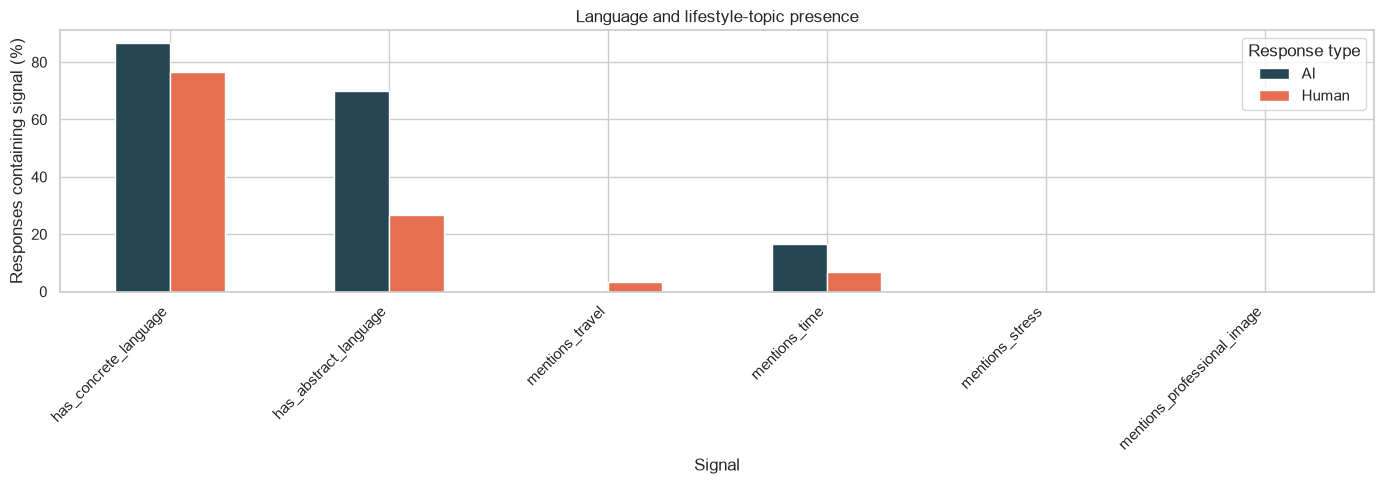

In [5]:
presence_columns = [column for column in metrics.columns if column.startswith('has_') or column.startswith('mentions_')]
presence = metrics.groupby('response_type')[presence_columns].mean().mul(100).round(1)
display(presence)
presence.T.plot(kind='bar', figsize=(14, 5), color=['#264653', '#e76f51'])
plt.title('Language and lifestyle-topic presence')
plt.ylabel('Responses containing signal (%)')
plt.xlabel('Signal')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Response type')
plt.tight_layout()

## Category-Level Comparison and Takeaways

In [6]:
category_summary = (metrics.groupby(['Question Category', 'response_type'])
                    [['word_count', 'lexical_diversity', 'concrete_term_count', 'abstract_term_count']]
                    .mean().round(2).reset_index())
display(category_summary)
print('Human answers are shorter on average than AI answers:', metrics.groupby('response_type')['word_count'].mean().round(1).to_dict())
print('Review flagged rows before treating artifacts as data errors; flags are screening signals.')

,Question Category,response_type,word_count,lexical_diversity,concrete_term_count,abstract_term_count
0,brand loyalty,AI,61.67,0.81,3.67,2.00
1,brand loyalty,Human,26.67,0.82,3.00,1.33
2,influences,AI,37.67,0.86,2.67,2.33
3,influences,Human,31.67,0.93,0.00,0.00
4,product preferences,AI,57.40,0.82,3.00,1.20
5,product preferences,Human,33.93,0.84,1.87,0.27
6,shopping behavior,AI,52.89,0.84,4.22,1.56
7,shopping behavior,Human,27.89,0.88,2.56,0.33


Human answers are shorter on average than AI answers: {'AI': 54.5, 'Human': 31.2}
Review flagged rows before treating artifacts as data errors; flags are screening signals.
